In [ ]:
# Install compatible versions
!pip install -q numpy==1.26.4 pandas==2.2.2 seaborn==0.13.2 facenet-pytorch==2.6.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.

In [ ]:
!pip install -q kagglehub
!pip install -q torch torchvision torchaudio
!pip install -q opencv-python-headless
!pip install -q scikit-learn seaborn tqdm
!pip install -q facenet-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 82.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 2.4.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you ha

Imports

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models

Drive Mounting

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs("/content/drive/MyDrive/deepfake_project", exist_ok=True)

MODEL_PATH = "/content/drive/MyDrive/deepfake_project/model.pth"

Mounted at /content/drive


Dataset Download

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download("reubensuju/celeb-df-v2")

print(dataset_path)

100%|██████████| 9.29G/9.29G [09:57<00:00, 16.7MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/reubensuju/celeb-df-v2/versions/1


In [ ]:
real_dir = os.path.join(dataset_path,"Celeb-real")
fake_dir = os.path.join(dataset_path,"Celeb-synthesis")

real_videos = [os.path.join(real_dir,v) for v in os.listdir(real_dir)][:300]
fake_videos = [os.path.join(fake_dir,v) for v in os.listdir(fake_dir)][:300]

video_paths = real_videos + fake_videos
labels = [0]*300 + [1]*300

In [ ]:
from facenet_pytorch import MTCNN

device = 'cuda' if torch.cuda.is_available() else 'cpu'

mtcnn = MTCNN(
    image_size=224,
    margin=20,
    device=device
)

In [ ]:
print(device)

cuda


In [ ]:
def load_video(video_path,seq_len=16):

    cap = cv2.VideoCapture(video_path)

    frames=[]

    while len(frames)<seq_len:

        ret,frame=cap.read()

        if not ret:
            break

        rgb=cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)

        face=mtcnn(rgb)

        if face is not None:
            frames.append(face.numpy())

    cap.release()

    if len(frames)==0:
        frames=[np.zeros((3,224,224))]*seq_len

    while len(frames)<seq_len:
        frames.append(frames[-1])

    frames=np.array(frames)

    return frames

In [ ]:
class DeepfakeDataset(Dataset):

    def __init__(self,video_paths,labels):

        self.video_paths=video_paths
        self.labels=labels

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self,idx):

        frames=load_video(self.video_paths[idx])

        frames=torch.tensor(frames).float()

        label=torch.tensor(self.labels[idx])

        return frames,label

In [ ]:
from sklearn.model_selection import train_test_split

train_videos,test_videos,train_labels,test_labels = train_test_split(
    video_paths,
    labels,
    test_size=0.2,
    stratify=labels
)

train_dataset=DeepfakeDataset(train_videos,train_labels)
test_dataset=DeepfakeDataset(test_videos,test_labels)

train_loader=DataLoader(train_dataset,batch_size=4,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=4)

In [ ]:
class DeepFakeDetector(nn.Module):

    def __init__(self):

        super().__init__()

        backbone=models.resnext50_32x4d(weights="IMAGENET1K_V2")

        self.features=nn.Sequential(*list(backbone.children())[:-2])

        self.pool=nn.AdaptiveAvgPool2d(1)

        self.lstm=nn.LSTM(
            input_size=2048,
            hidden_size=256,
            num_layers=1,
            batch_first=True
        )

        self.dropout=nn.Dropout(0.5)
        self.lstm = nn.LSTM(2048,256,batch_first=True,dropout=0.3)

        self.fc=nn.Linear(256,2)

    def forward(self,x):

        b,t,c,h,w=x.shape

        x=x.view(b*t,c,h,w)

        f=self.features(x)

        f=self.pool(f)

        f=f.view(b,t,2048)

        lstm_out,_=self.lstm(f)

        out=lstm_out[:,-1,:]

        out=self.dropout(out)

        out=self.fc(out)

        return out

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=DeepFakeDetector().to(device)

criterion=nn.CrossEntropyLoss()

optimizer=torch.optim.Adam(model.parameters(),lr=1e-4)

scheduler=torch.optim.lr_scheduler.StepLR(optimizer,step_size=5,gamma=0.5)

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth
100%|██████████| 95.8M/95.8M [00:00<00:00, 186MB/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


In [ ]:
if os.path.exists(MODEL_PATH):
    print("Loading saved model...")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device('cpu')))
    model.eval()
else:
    print("No saved model found. Training will start...")

Loading saved model...


TRAINING LOOP!!!

In [ ]:
epochs=20

for epoch in range(epochs):

    model.train()

    total_loss=0

    for videos,labels in tqdm(train_loader):

        videos=videos.to(device)
        labels=labels.to(device)

        optimizer.zero_grad()

        outputs=model(videos)

        loss=criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        total_loss+=loss.item()

    scheduler.step()

    print("Epoch:",epoch+1,"Loss:",total_loss)

    torch.save(model.state_dict(), MODEL_PATH)

100%|██████████| 120/120 [11:13<00:00,  5.62s/it]


Epoch: 1 Loss: 79.00071260333061


100%|██████████| 120/120 [11:44<00:00,  5.87s/it]


Epoch: 2 Loss: 48.120868504047394


100%|██████████| 120/120 [11:47<00:00,  5.90s/it]


...

Epoch: 18 Loss: 0.29008676543890033


100%|██████████| 120/120 [11:17<00:00,  5.65s/it]


Epoch: 19 Loss: 0.16072393956710584


100%|██████████| 120/120 [11:04<00:00,  5.54s/it]


Epoch: 20 Loss: 0.19778767960087862


In [ ]:
model.eval()

y_true=[]
y_pred=[]

with torch.no_grad():

    for videos,labels in test_loader:

        videos=videos.to(device)

        outputs=model(videos)

        preds=torch.argmax(outputs,1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

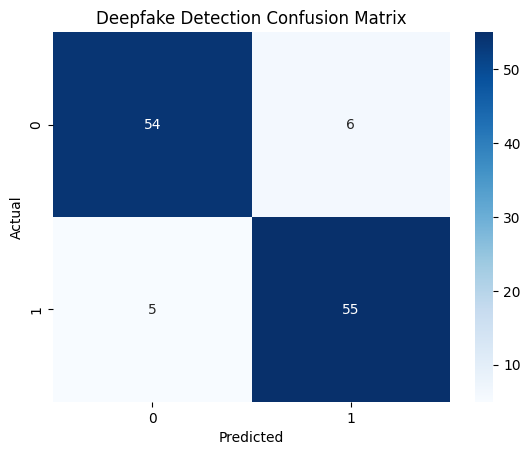

In [ ]:
cm=confusion_matrix(y_true,y_pred)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Deepfake Detection Confusion Matrix")

plt.show()

In [ ]:
print("CLASSIFICATION REPORT")
print(classification_report(y_true,y_pred))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.90      0.91        60
           1       0.90      0.92      0.91        60

    accuracy                           0.91       120
   macro avg       0.91      0.91      0.91       120
weighted avg       0.91      0.91      0.91       120



In [ ]:
def predict_video(video_path):

    frames = load_video(video_path)

    frames = torch.tensor(frames).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(frames)
        probabilities = torch.softmax(output, dim=1)
        prob_fake = probabilities[0, 1].item()
    if prob_fake > 0.6:
        print("Deepfake Video")
    else:
        print("Real Video")

    print("Confidence (Fake):", prob_fake)

Upload your video here

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving id13_id10_0011.mp4 to id13_id10_0011.mp4


In [ ]:
video_path = list(uploaded.keys())[0]

print("Uploaded video:", video_path)

Uploaded video: id13_id10_0011.mp4


In [ ]:
predict_video(video_path)

Deepfake Video
Confidence (Fake): 0.9397165179252625
